# Fit a 2-D Exponential to a 2-D histogram of star counts from Match Filter
## Charlotte Christensen, June 18, 2026

In [1]:
import numpy as np
from astropy.io import fits
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

In [2]:
box = 'storm'
num = '2'
galaxy_name = f'{box}_{num}'

In [3]:
hdul = fits.open(f'../matched_filter/mf_data/outputs/{galaxy_name}_mf.fits')

In [4]:
data=hdul[0].data

In [5]:
hdul.info()

Filename: ../matched_filter/mf_data/outputs/storm_2_mf.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       7   (89, 89)   float64   


In [6]:
# 1. Define the 2-D exponential model function
# The first argument must accept the combined X and Y coordinate array
def exponential_2d(coords, A, h, q, x_offset, y_offset, theta, C):
    # Parameters: A is amplitude, h is scale length, q is axis ratio (ie., minor/major; related to orientation), 
    # theta is rotation angle in viewing plane, C is offset from background (should be about zero)
    # theta = 0 means major axis is along x-axis, theta = pi/2 means major axis is along y-axis
    x = coords[0] - x_offset
    y = coords[1] - y_offset
    x_prime = x * np.cos(theta) + y * np.sin(theta)
    y_prime = -x * np.sin(theta) + y * np.cos(theta)
    r = np.sqrt(x_prime**2 + y_prime**2/q**2)
    return A * np.exp(-r/h) + C

In [7]:
# 2. Generate synthetic mock data with noise
x_line = np.linspace(-60, 60, 89)
y_line = np.linspace(-60, 60, 89)
X, Y = np.meshgrid(x_line, y_line)

# 3. Flatten the arrays to 1-D for curve_fit
x_flat = X.ravel()
y_flat = Y.ravel()
z_flat = data.ravel()

# Combine independent variables into an (2, N) shaped array
independent_vars = np.vstack((x_flat, y_flat))

In [8]:
# 4. Provide a sensible initial guess (p0) to prevent divergence
# Form: [A, h, q, x_offset, y_offset, theta, C]
initial_guess = [7, 2, 2, 10, 0, 0, 0]

# 5. Perform the optimization
fitted_params, covariance = curve_fit(
    f=exponential_2d, 
    xdata=independent_vars, 
    ydata=z_flat, 
    p0=initial_guess
)

In [9]:
# 6. Extract and view results
A_fit, h_fit, q_fit, x_offset_fit, y_offset_fit, theta_fit, C_fit= fitted_params
print("Fitted Parameters:")
print(f"A  = {A_fit:.4f}")
print(f"h = {h_fit:.4f}")
print(f"q = {q_fit:.4f}")
print(f"x_offset = {x_offset_fit:.4f}")
print(f"y_offset = {y_offset_fit:.4f}")
print(f"C  = {C_fit:.4f}")
print(f"theta = {theta_fit:.4f}")

Fitted Parameters:
A  = 596.1692
h = 2.0006
q = 1.9187
x_offset = 6.7210
y_offset = -0.6218
C  = 0.0289
theta = -0.1143


In [10]:
Z_fitted = exponential_2d((X, Y), *fitted_params)

[ 0.05961982  0.59619816  5.96198165 59.61981645]


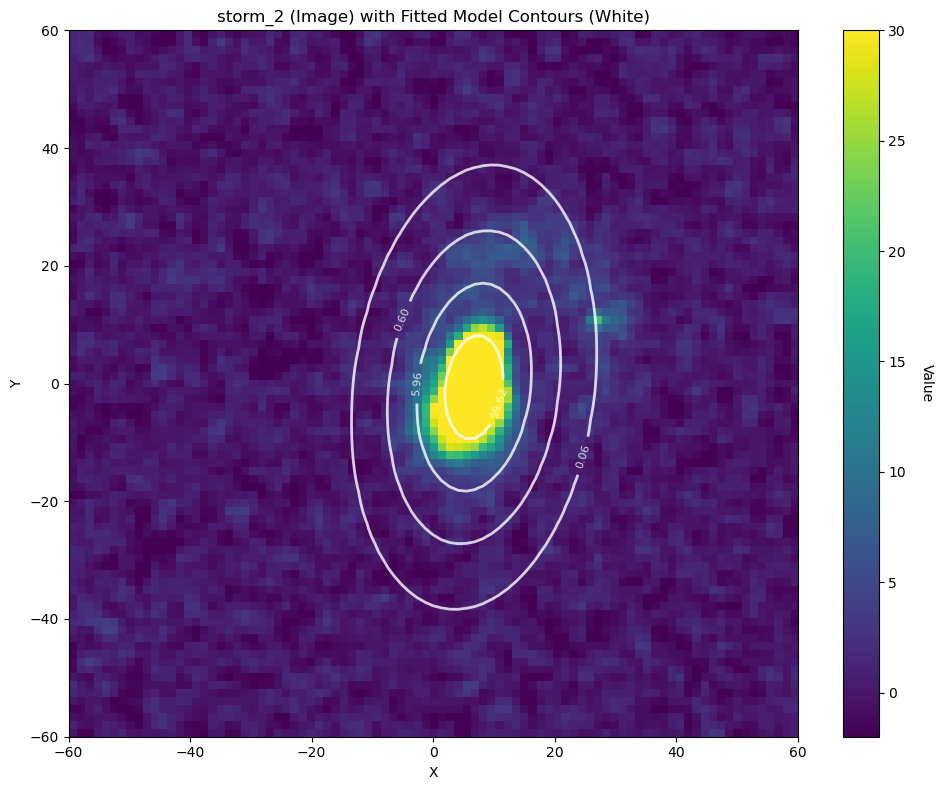

In [11]:
def twod_exp_fit(save=True):

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot the original noisy data as an image
    im = ax.imshow(data, origin='lower', extent=[x_line.min(), x_line.max(), y_line.min(), y_line.max()], 
                   cmap='viridis', vmin=-2, vmax=30, aspect='auto')

    # Overlay contours of the fitted result
    levels_arr = 10.0**np.array([-4,-3,-2,-1])*(A_fit + C_fit)
    print(levels_arr)
    contours = ax.contour(X, Y, Z_fitted, colors='white', linewidths=2, levels=levels_arr, alpha=0.8)
    ax.clabel(contours, inline=True, fontsize=8, fmt='%.2f')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Value', rotation=270, labelpad=20)

    # Labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'{galaxy_name} (Image) with Fitted Model Contours (White)')

    plt.tight_layout()

    if save==True:
        plt.savefig(f'sd_outputs/2D_exponential_fit/{galaxy_name}/{galaxy_name}_fitted.png')
    
    plt.show()

twod_exp_fit()

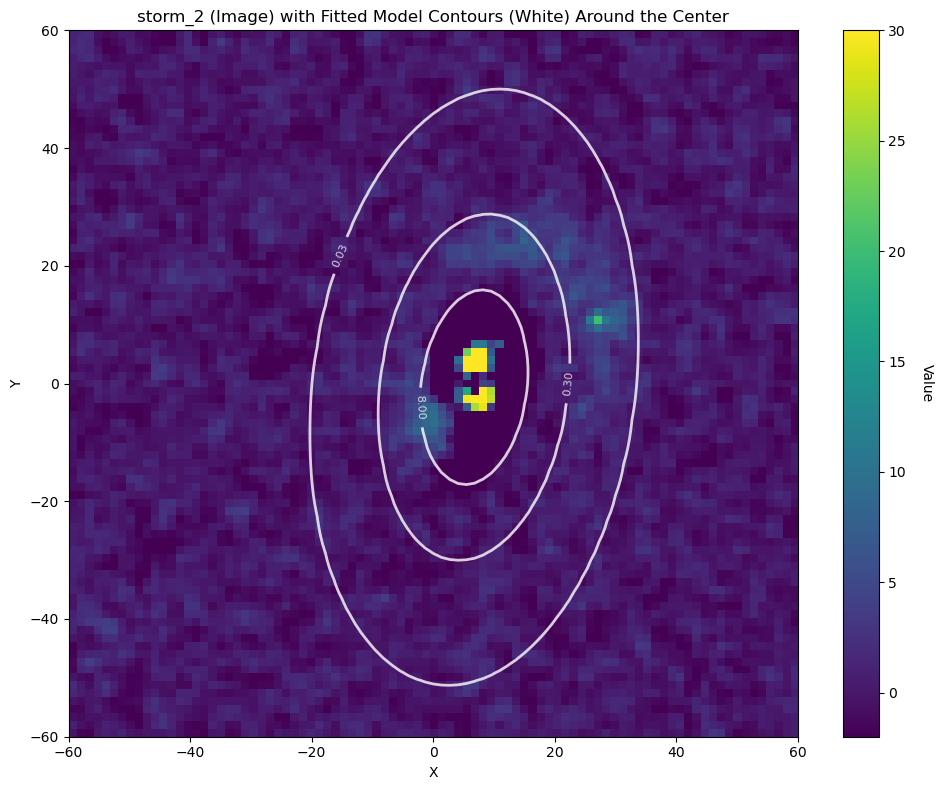

In [12]:
def twod_exp_fit_reduced(save=True):

    # Create figure and axis
    fig, ax = plt.subplots(figsize=(10, 8))

    # Plot the original noisy data as an image
    im = ax.imshow(data-Z_fitted, origin='lower', extent=[x_line.min(), x_line.max(), y_line.min(), y_line.max()], 
                   cmap='viridis', vmin=-2, vmax=30, aspect='auto')

    # Overlay contours of the fitted result
    contours = ax.contour(X, Y, Z_fitted, colors='white', linewidths=2, levels=[0.03, 0.3, 8], alpha=0.8)
    ax.clabel(contours, inline=True, fontsize=8, fmt='%.2f')

    # Add colorbar
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Value', rotation=270, labelpad=20)

    # Labels and title
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax.set_title(f'{galaxy_name} (Image) with Fitted Model Contours (White) Around the Center')

    plt.tight_layout()

    if save==True:
        plt.savefig(f'sd_outputs/2D_exponential_fit/{galaxy_name}/{galaxy_name}_fitted_reduced.png')

    plt.show()

twod_exp_fit_reduced()